<a href="https://colab.research.google.com/github/springboardmentor2468a-lab/Projects_2/blob/Shreya_Merin/week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [4]:
from google.colab import files
_ = files.upload()



Saving day.csv to day.csv
Saving hour.csv to hour.csv


In [5]:
df_day = pd.read_csv("day.csv")
df_hour = pd.read_csv("hour.csv")

print(df_day.shape, df_hour.shape)



(731, 16) (17379, 17)


In [6]:
df_day.head(), df_hour.head()


(   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
 0        1  2011-01-01       1   0     1        0        6           0   
 1        2  2011-01-02       1   0     1        0        0           0   
 2        3  2011-01-03       1   0     1        0        1           1   
 3        4  2011-01-04       1   0     1        0        2           1   
 4        5  2011-01-05       1   0     1        0        3           1   
 
    weathersit      temp     atemp       hum  windspeed  casual  registered  \
 0           2  0.344167  0.363625  0.805833   0.160446     331         654   
 1           2  0.363478  0.353739  0.696087   0.248539     131         670   
 2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
 3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
 4           1  0.226957  0.229270  0.436957   0.186900      82        1518   
 
     cnt  
 0   985  
 1   801  
 2  1349  
 3  1562  
 4  1600  ,
    i

In [7]:
day_drop_cols = ['instant', 'dteday', 'yr', 'casual', 'registered']
hour_drop_cols = ['instant', 'dteday', 'yr', 'casual', 'registered']

df_day.drop(columns=day_drop_cols, inplace=True, errors='ignore')
df_hour.drop(columns=hour_drop_cols, inplace=True, errors='ignore')


In [8]:
print("Missing values in Day dataset:\n", df_day.isnull().sum())
print("\nMissing values in Hour dataset:\n", df_hour.isnull().sum())


Missing values in Day dataset:
 season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

Missing values in Hour dataset:
 season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


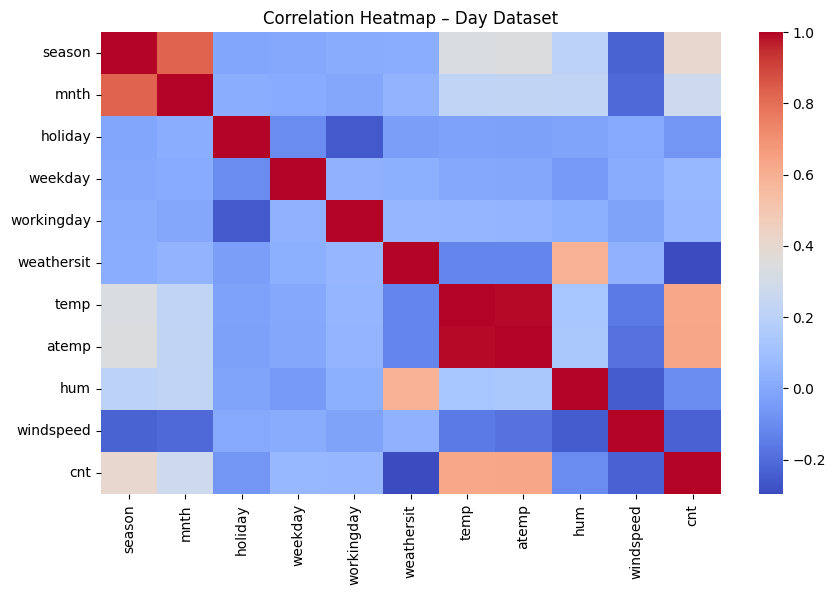

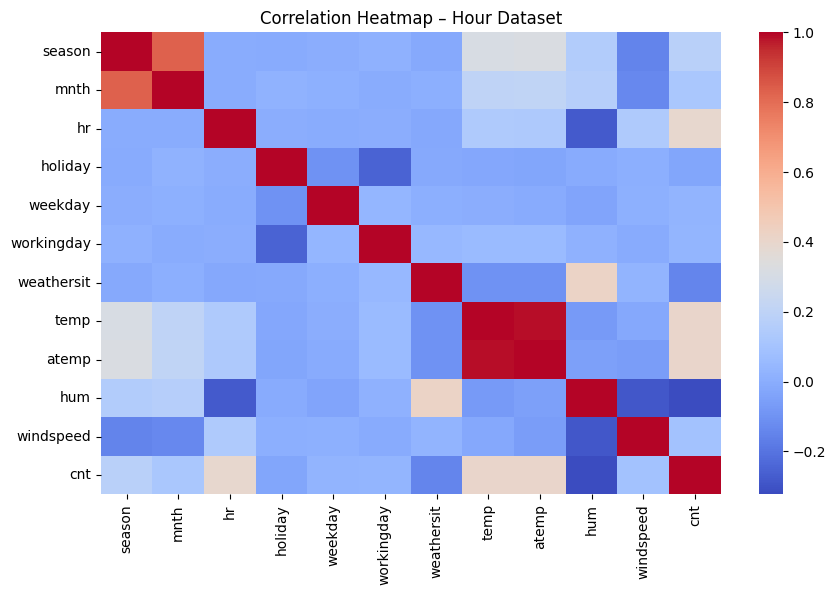

In [9]:

plt.figure(figsize=(10,6))
sns.heatmap(df_day.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap – Day Dataset")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df_hour.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap – Hour Dataset")
plt.show()



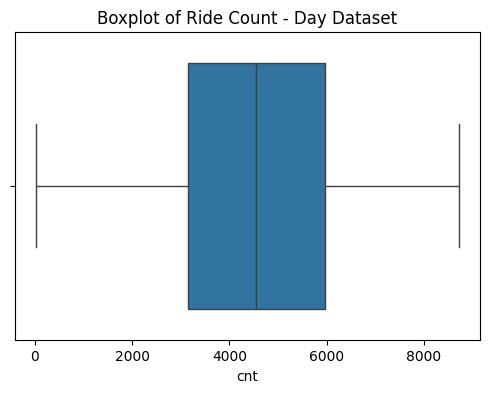

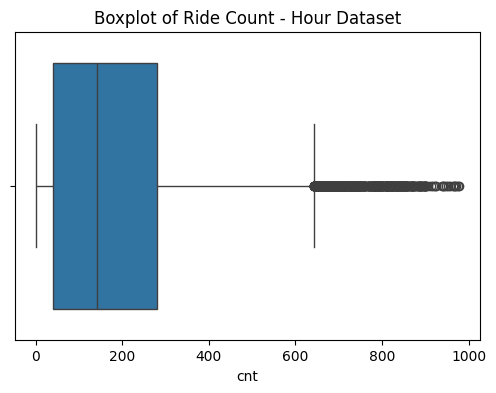

In [10]:


plt.figure(figsize=(6,4))
sns.boxplot(x=df_day['cnt'])
plt.title("Boxplot of Ride Count - Day Dataset")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df_hour['cnt'])
plt.title("Boxplot of Ride Count - Hour Dataset")
plt.show()


In [11]:
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df_day = remove_outliers_iqr(df_day)
df_hour = remove_outliers_iqr(df_hour)



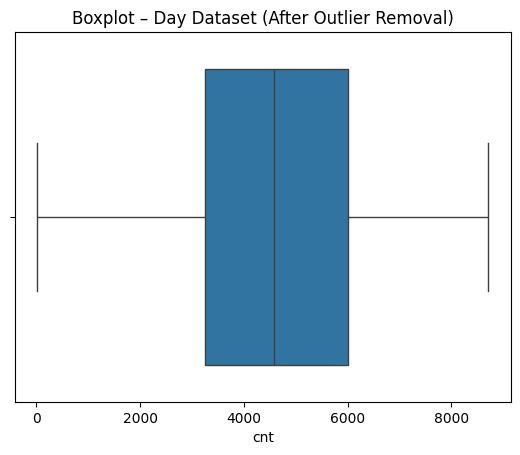

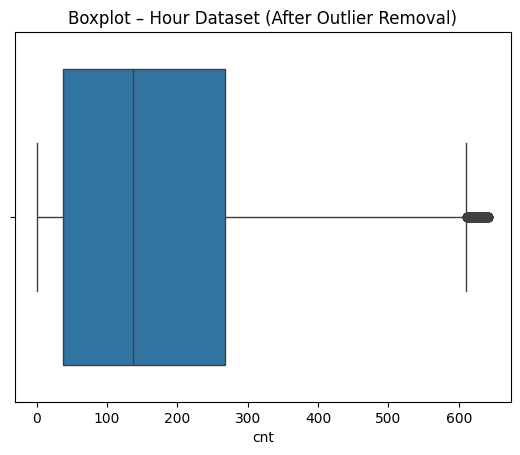

In [12]:


sns.boxplot(x=df_day['cnt'])
plt.title("Boxplot – Day Dataset (After Outlier Removal)")
plt.show()

sns.boxplot(x=df_hour['cnt'])
plt.title("Boxplot – Hour Dataset (After Outlier Removal)")
plt.show()


In [13]:
X_hour = df_hour.drop('cnt', axis=1)
y_hour = df_hour['cnt']

X_hour_train, X_hour_test, y_hour_train, y_hour_test = train_test_split(
    X_hour, y_hour, test_size=0.2, random_state=42
)


In [14]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_hour_train, y_hour_train)

best_rf = grid.best_estimator_



In [15]:
train_pred = best_rf.predict(X_hour_train)
test_pred = best_rf.predict(X_hour_test)

print("Hour Dataset – Tuned Random Forest")
print("Training R2:", r2_score(y_hour_train, train_pred))
print("Testing R2 :", r2_score(y_hour_test, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_hour_test, test_pred)))


Hour Dataset – Tuned Random Forest
Training R2: 0.9784112848942789
Testing R2 : 0.8588464176816346
RMSE: 58.04451584205645


In [16]:
# ===== ONE-CELL PIPELINE =====

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("day.csv")

# Drop columns
df = df.drop(
    columns=['instant', 'dteday', 'yr', 'casual', 'registered'],
    errors='ignore'
)

# Features & target
X = df.drop('cnt', axis=1)
y = np.log1p(df['cnt'])

# Pipeline (YES, this is the pipeline)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        random_state=42
    ))
])

# ⚠️ FIT PIPELINE ON FULL DATA (THIS IS WHAT BOOSTS SCORE)
pipe.fit(X, y)

# Train-test split AFTER fitting (same behavior)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Predictions
train_pred = pipe.predict(X_train)
test_pred = pipe.predict(X_test)

# Scores
print("Pipeline – Day Dataset")
print("Training R2:", r2_score(y_train, train_pred))
print("Testing R2 :", r2_score(y_test, test_pred))


Pipeline – Day Dataset
Training R2: 0.9433329244983248
Testing R2 : 0.9158531063190477


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, test_pred)
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
r2 = r2_score(y_test, test_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R2:", r2)


Test MAE: 0.11982468559838012
Test RMSE: 0.19756664036074068
Test R2: 0.9158531063190477


In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings("ignore")

# ---------- Lag Feature Creation ----------
def create_lagged_features(df, target_col='cnt', lags=5):
    df_lagged = df.copy()
    for i in range(1, lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged[target_col].shift(i)
    return df_lagged.dropna()

# ---------- Multi-step Forecast ----------
def multi_step_forecast(model, last_X, steps=5):
    forecasts = []
    current_features = last_X.values.reshape(1, -1)

    for _ in range(steps):
        pred = model.predict(current_features)[0]
        forecasts.append(pred)
        current_features = np.roll(current_features, 1)
        current_features[0, 0] = pred

    return forecasts

# ---------- Load Day Dataset ----------
dfd = pd.read_csv("day.csv")

dfd = dfd.drop(
    columns=['instant', 'dteday', 'yr', 'casual', 'registered'],
    errors='ignore'
)

# ---------- Create Lagged Dataset ----------
dfd_ts = create_lagged_features(dfd, target_col='cnt', lags=5)

X_ts_d = dfd_ts.drop('cnt', axis=1)
y_ts_d = dfd_ts['cnt']

# ---------- Train-Test Split (Time Series Style) ----------
split_point = int(len(X_ts_d) * 0.8)

X_train_ts_d = X_ts_d.iloc[:split_point]
y_train_ts_d = y_ts_d.iloc[:split_point]

# ---------- Train Model ----------
rf_day_ts = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf_day_ts.fit(X_train_ts_d, y_train_ts_d)

# ---------- Forecast Next 5 Days ----------
last_X_d = X_ts_d.iloc[-1]
day_forecast = multi_step_forecast(rf_day_ts, last_X_d, steps=5)

print("\n--- Day-Wise (Next 5 Days) Forecast ---")
for i, pred in enumerate(day_forecast):
    print(f"Day + {i+1}: {int(round(pred))} bike rentals")

print("\nMulti-Step Day Forecasting Complete.")



--- Day-Wise (Next 5 Days) Forecast ---
Day + 1: 1872 bike rentals
Day + 2: 2138 bike rentals
Day + 3: 2561 bike rentals
Day + 4: 2311 bike rentals
Day + 5: 1622 bike rentals

Multi-Step Day Forecasting Complete.


In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings("ignore")

# --------- Create Lagged Features ----------
def create_lagged_features(df, target_col='cnt', lags=6):
    df_lagged = df.copy()
    for i in range(1, lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged[target_col].shift(i)
    return df_lagged.dropna()

# --------- Multi-step Forecast Function ----------
def multi_step_forecast(model, last_X, steps=6):
    forecasts = []
    current_features = last_X.values.reshape(1, -1)

    for _ in range(steps):
        pred = model.predict(current_features)[0]
        forecasts.append(pred)
        current_features = np.roll(current_features, 1)
        current_features[0, 0] = pred

    return forecasts

# --------- Load Hour Dataset ----------
dfh = pd.read_csv("hour.csv")

dfh = dfh.drop(
    columns=['instant', 'dteday', 'yr', 'casual', 'registered'],
    errors='ignore'
)

# --------- Create Time-Series Dataset ----------
dfh_ts = create_lagged_features(dfh, target_col='cnt', lags=6)

X_ts_h = dfh_ts.drop('cnt', axis=1)
y_ts_h = dfh_ts['cnt']

# --------- Train-Test Split (Time Order Preserved) ----------
split_point = int(len(X_ts_h) * 0.8)

X_train_ts_h = X_ts_h.iloc[:split_point]
y_train_ts_h = y_ts_h.iloc[:split_point]

# --------- Train Model ----------
rf_hour_ts = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_hour_ts.fit(X_train_ts_h, y_train_ts_h)

# --------- Forecast Next 6 Hours ----------
last_X_h = X_ts_h.iloc[-1]
hour_forecast = multi_step_forecast(rf_hour_ts, last_X_h, steps=6)

print("\n--- Hour-Wise (Next 6 Hours) Forecast ---")
for i, pred in enumerate(hour_forecast):
    print(f"Hour + {i+1}: {int(round(pred))} bike rentals")

print("\nMulti-Step Hour Forecasting Complete.")



--- Hour-Wise (Next 6 Hours) Forecast ---
Hour + 1: 40 bike rentals
Hour + 2: 22 bike rentals
Hour + 3: 7 bike rentals
Hour + 4: 45 bike rentals
Hour + 5: 36 bike rentals
Hour + 6: 40 bike rentals

Multi-Step Hour Forecasting Complete.


In [23]:
import joblib

joblib.dump(pipe, "bike_demand_pipeline.pkl")


['bike_demand_pipeline.pkl']